## Βαθιά Μάθηση : Εργασία 2025-2026

#### Δημήτριος Μουταφτσίδης , 9920
#### moutdimi@ece.atuh.gr

### 1. Συναρτήσεις εκπαίδευσης και αξιολόγησης.
Όλες οι συναρτήσεις αυτής της ενότητας χρησιμοποιούνται αυτούσιες από το ερώτημα 1. Επαναλαμβάνονται παρακάτω άνευ σχολίων.

In [8]:
#Basic libraries we need for different operations.
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time
import os
import glob
import copy
import pickle

#Basic torch modules, including transformations, dataloaders etc.
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms , models

#Importing the Neural Network modules as well as the optimizer.
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

#Sickit-Learn offers very neat performance metrics.
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score

#Importing the libraries containing the dataset. 
import medmnist
from medmnist import INFO
from medmnist import PneumoniaMNIST

In [9]:
transform = transforms.Compose([transforms.ToTensor() , transforms.Lambda(lambda x : x.repeat(3 , 1 , 1)) , transforms.Normalize(mean = [0.485 , 0.456 , 0.406], std = [0.229 , 0.224 , 0.225])])

root = r"C:\Users\dimit\Desktop\Βαθιά Μάθηση"

training_dataset = PneumoniaMNIST(split="train" , download = True , root = root , transform = transform)
validation_dataset   = PneumoniaMNIST(split="val" , download = True , root = root , transform =transform)

batch_size = 64
training_dataloader = DataLoader(training_dataset , batch_size = batch_size , shuffle = True , num_workers = 0)
validation_dataloader   = DataLoader(validation_dataset , batch_size = batch_size , shuffle = False , num_workers = 0)

test_dataset = PneumoniaMNIST(split = "test" , download = True, root = root , transform = transform)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False , num_workers = 0)

images , labels = next(iter(training_dataloader))
print(images.shape)
print(labels.shape, labels.dtype)

print(len(training_dataset) , len(validation_dataset) , len(test_dataset)) 
print(training_dataset.split, validation_dataset.split , test_dataset.split) 

torch.Size([64, 3, 28, 28])
torch.Size([64, 1]) torch.int32
4708 524 624
train val test


In [1]:
def Train_Classifier(model, initial_lr , weight_decay , num_epochs , training_dataloader, validation_dataloader , use_scheduler = False , weight = None):

    criterion = nn.CrossEntropyLoss(weight = weight)
    optimizer = torch.optim.Adam(model.parameters(), lr = initial_lr , weight_decay = weight_decay)
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer , mode = "min" , factor = 0.5, patience = 2 , threshold = 1e-3 ,
                                                               threshold_mode = "abs" , cooldown = 1 , min_lr = 1e-6)
    else:
        scheduler = None
        

    with_accuracy = None
    at_epoch = None
    best_validation_loss = float("inf")
    best_validation_accuracy = 0.0
    best_state = None
    best_epoch = None

    training_accuracies = []
    validation_accuracies = []
    training_losses = []
    validation_losses = []

    start = time.time()

    for epoch in range(1, num_epochs + 1):

        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in training_dataloader:
            labels = labels.squeeze(1).long()
            optimizer.zero_grad()
            scores = model(images)
            loss = criterion(scores, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            predictions = scores.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        epoch_training_loss = running_loss / len(training_dataloader.dataset)
        epoch_training_accuracy = correct / total
        training_losses.append(epoch_training_loss)
        training_accuracies.append(epoch_training_accuracy)

        model.eval()
        correct = 0
        total = 0
        running_loss = 0.0

        with torch.no_grad():
            for images, labels in validation_dataloader:
                labels = labels.squeeze(1).long()
                scores = model(images)
                loss = criterion(scores, labels)

                running_loss += loss.item() * images.size(0)
                predictions = scores.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        epoch_validation_loss = running_loss / len(validation_dataloader.dataset)
        epoch_validation_accuracy = correct / total
        validation_losses.append(epoch_validation_loss)
        validation_accuracies.append(epoch_validation_accuracy)

        if scheduler is not None:
            scheduler.step(epoch_validation_loss)

        if epoch_validation_loss < best_validation_loss:
            best_validation_loss = epoch_validation_loss
            with_accuracy = epoch_validation_accuracy
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch_validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = epoch_validation_accuracy
            at_epoch = epoch

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_training_loss:.4f}, acc: {epoch_training_accuracy:.4f} | "
            f"Val loss: {epoch_validation_loss:.4f}, acc: {epoch_validation_accuracy:.4f}"
        )

    training_time = round((time.time() - start) / 60, 2)
    print("Training time (minutes):", training_time)
    print("Best epoch: ", best_epoch , "with loss " , round(best_validation_loss, 5) , "and accuracy ", round(with_accuracy * 100 , 2),"%.") 
    print("Best validation accuracy: " , round(best_validation_accuracy * 100 , 2) , "% at epoch " , at_epoch ,".")

    if best_state is not None:
        model.load_state_dict(best_state)

    results = {
        "training_losses": training_losses ,
        "validation_losses": validation_losses ,
        "training_accuracies": training_accuracies ,
        "validation_accuracies": validation_accuracies ,
        "best_validation_accuracy": best_validation_accuracy ,
        "best_validation_loss" : best_validation_loss , 
        "best_epoch": best_epoch ,
        "training_time_min": training_time ,
        "initial_lr": initial_lr ,
        "num_epochs": num_epochs ,
        "model_name": model.__class__.__name__,
    }

    return model, best_state, results


In [4]:
def Test_Classifier(model , dataloader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    current_loss = 0.0
    correct = 0
    total = 0 

    agg_predictions =[]
    agg_labels = []

    with torch.no_grad():
        for images , labels in dataloader:
            labels = labels.squeeze(1).long()

            scores = model(images)    
            loss = criterion(scores , labels)

            current_loss += loss.item() * images.size(0)

            predictions = scores.argmax(dim = 1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            agg_predictions.append(predictions.cpu().numpy())
            agg_labels.append(labels.cpu().numpy())

    avrg_loss = current_loss / len(dataloader.dataset)
    accuracy = correct / total

    model_predictions = np.concatenate(agg_predictions)
    true_labels = np.concatenate(agg_labels)

    cm = confusion_matrix(true_labels , model_predictions)
    report = classification_report(true_labels , model_predictions , digits = 4)

    return cm , report , avrg_loss , accuracy

In [5]:
def Plot_Classifier_Curves(results):

    #Extract values lists for plot creation. 
    training_losses = results["training_losses"]
    validation_losses = results["validation_losses"]
    training_accuracies = results["training_accuracies"]
    validation_accuracies = results["validation_accuracies"]

    epochs = range(1 , len(training_losses) + 1)

    #Plot losses.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_losses , label = "Training loss")
    plt.plot(epochs , validation_losses , label = "Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #Plot accuracies.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_accuracies , label = "Training accuracy")
    plt.plot(epochs , validation_accuracies , label = "Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def Plot_CM(cm , class_names = ("Normal - 0" , "Pneumonia - 1")):

    fmt = "d"
    
    plt.figure(figsize = (5 , 5))
    plt.imshow(cm , interpolation = "nearest" , cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks , class_names , rotation = 45)
    plt.yticks(tick_marks , class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                format(value, fmt),
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )
    
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

### ResNet-18.
Το μοντέλο και τα βάρη περιλαμβάνονται αυτούσια εντός της Torch. Από εκεί εύκολα το φορτώνουμε στο Notebook.

In [12]:
#Load weights and models.
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights = weights)

model.fc = torch.nn.Linear(model.fc.in_features, 2)

In [14]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

#In order to make the dataset compatible, we resize to imagenet sizes and clone image to simulate RGB channels.
#We also normalize using the stats of ImageNet. We got the online.
transform = transforms.Compose([transforms.Resize((224, 224)) ,transforms.ToTensor() , transforms.Lambda(lambda x : x.repeat(3 , 1 , 1)) , transforms.Normalize(mean = [0.485 , 0.456 , 0.406], std = [0.229 , 0.224 , 0.225])])

root = r"C:\Users\dimit\Desktop\Βαθιά Μάθηση"

#Now we download, create dataloaders after applying the transforms and sanity-check image sizes.
training_dataset = PneumoniaMNIST(split="train" , download = True , root = root , transform = transform)
validation_dataset   = PneumoniaMNIST(split="val" , download = True , root = root , transform =transform)

batch_size = 64
training_dataloader = DataLoader(training_dataset , batch_size = batch_size , shuffle = True , num_workers = 0)
validation_dataloader   = DataLoader(validation_dataset , batch_size = batch_size , shuffle = False , num_workers = 0)

test_dataset = PneumoniaMNIST(split = "test" , download = True, root = root , transform = transform)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False , num_workers = 0)

images , labels = next(iter(training_dataloader))
print(images.shape)
print(labels.shape, labels.dtype)

print(len(training_dataset) , len(validation_dataset) , len(test_dataset)) 
print(training_dataset.split, validation_dataset.split , test_dataset.split) 

torch.Size([64, 3, 224, 224])
torch.Size([64, 1]) torch.int32
4708 524 624
train val test


Για να εκπαιδεύσουμε μόνο ένα τμήμα του μοντέλου, παγώνουμε τα πάντα μέσω της requires_grad = False. Στην συνέχει επανενεργοποιούμε μόνο το επιθυμητό τμήμα του μοντέλου.

In [17]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

model_clh = resnet18(weights = weights)

#We adjust the classifier output to 2, thus matching current classification task.
model_clh.fc = torch.nn.Linear(model_clh.fc.in_features, 2)

#We freeze everything.
for p in model_clh.parameters():
    p.requires_grad = False

#And the unfreeze only classifier head.
for p in model_clh.fc.parameters():
    p.requires_grad = True

#Quick curiosity-driven checks on the number of parameters we train on, vs total parameters.
trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

1026 11177538


### 3. Πειράματα.
Για κάθε πείραμα που ακολουθεί, φορτώνουμε εκ νέου το μοντέλο και επαναλαμβάνουμε τις διαδικασίες  απενεργοποίησης-ενεργοποίησης παραμέτρων. Έτσι εξασφαλίζουμε ότι το μοντέλο εκπαιδεύεται εκ νέου. Χρησιμοποιούμε παντού seed. Ο κώδικας είναι επαναλαμβανόμενος και τετρημένος. Τα σχόλια που έγιναν παραπάνω ισχύουν για όλα τα πειράματα.

Epoch 01 | Train loss: 0.3571, acc: 0.8447 | Val loss: 0.2909, acc: 0.8836
Epoch 02 | Train loss: 0.2380, acc: 0.9027 | Val loss: 0.2404, acc: 0.8969
Epoch 03 | Train loss: 0.2064, acc: 0.9131 | Val loss: 0.2370, acc: 0.8989
Epoch 04 | Train loss: 0.1928, acc: 0.9235 | Val loss: 0.2212, acc: 0.8989
Epoch 05 | Train loss: 0.1898, acc: 0.9235 | Val loss: 0.2551, acc: 0.8893
Epoch 06 | Train loss: 0.1812, acc: 0.9235 | Val loss: 0.2121, acc: 0.9046
Epoch 07 | Train loss: 0.1839, acc: 0.9276 | Val loss: 0.2073, acc: 0.9027
Epoch 08 | Train loss: 0.1752, acc: 0.9274 | Val loss: 0.2053, acc: 0.9103
Epoch 09 | Train loss: 0.1717, acc: 0.9325 | Val loss: 0.2169, acc: 0.9046
Epoch 10 | Train loss: 0.1741, acc: 0.9286 | Val loss: 0.2095, acc: 0.9160
Epoch 11 | Train loss: 0.1730, acc: 0.9282 | Val loss: 0.2196, acc: 0.9065
Epoch 12 | Train loss: 0.1632, acc: 0.9314 | Val loss: 0.2141, acc: 0.9103
Epoch 13 | Train loss: 0.1632, acc: 0.9363 | Val loss: 0.2181, acc: 0.9122
Epoch 14 | Train loss: 0.

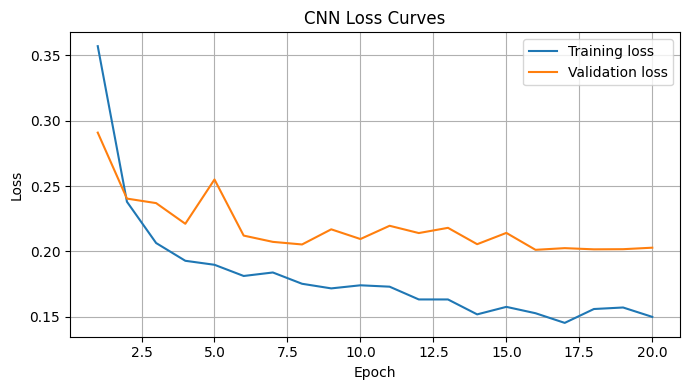

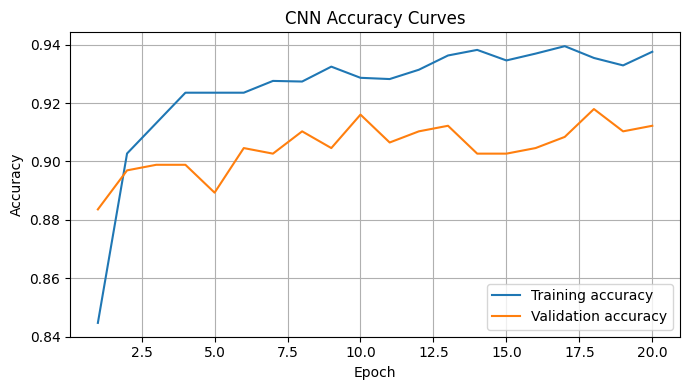

On the VALIDATION SET.
Model average loss: 0.201       Model accuracy: 90.458%

              precision    recall  f1-score   support

           0     0.8346    0.7852    0.8092       135
           1     0.9270    0.9460    0.9364       389

    accuracy                         0.9046       524
   macro avg     0.8808    0.8656    0.8728       524
weighted avg     0.9032    0.9046    0.9036       524



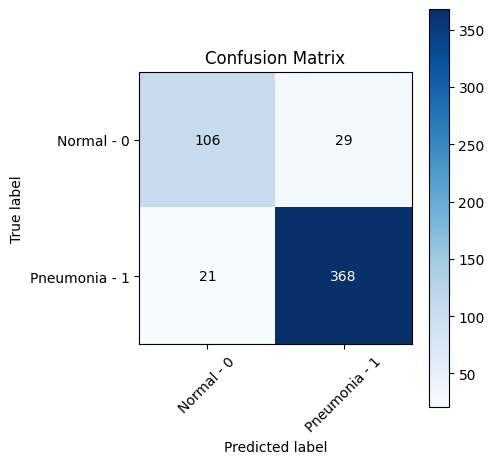

On the TEST SET.
Model average loss: 0.375       Model accuracy: 84.615%

              precision    recall  f1-score   support

           0     0.9539    0.6197    0.7513       234
           1     0.8114    0.9821    0.8886       390

    accuracy                         0.8462       624
   macro avg     0.8827    0.8009    0.8200       624
weighted avg     0.8649    0.8462    0.8371       624



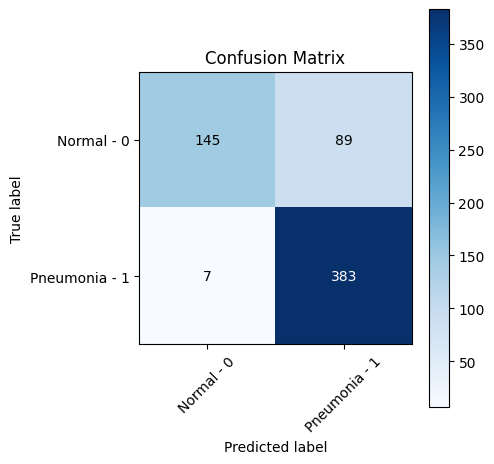

In [19]:
#Training Classifier Head 1.

model_clh_exp1 , best_state_clh_exp1 , results_clh_exp1 = Train_Classifier(
    model = model_clh ,
    initial_lr = 1e-3 ,
    weight_decay = 0 ,
    num_epochs = 20 ,
    training_dataloader = training_dataloader,
    validation_dataloader = validation_dataloader ,
    use_scheduler = True
)

torch.save(results_clh_exp1 , "results_clh_exp1.pt")
torch.save(best_state_clh_exp1 , "best_state_clh_exp1.pt")

Plot_Classifier_Curves(results_clh_exp1)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_exp1 , dataloader = validation_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_exp1 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

1026 11177538
Epoch 01 | Train loss: 0.3949, acc: 0.8226 | Val loss: 0.3027, acc: 0.8779
Epoch 02 | Train loss: 0.2540, acc: 0.8957 | Val loss: 0.2539, acc: 0.8836
Epoch 03 | Train loss: 0.2150, acc: 0.9144 | Val loss: 0.2432, acc: 0.8817
Epoch 04 | Train loss: 0.2011, acc: 0.9182 | Val loss: 0.2263, acc: 0.9046
Epoch 05 | Train loss: 0.1974, acc: 0.9220 | Val loss: 0.2165, acc: 0.9027
Epoch 06 | Train loss: 0.1853, acc: 0.9271 | Val loss: 0.2252, acc: 0.8969
Epoch 07 | Train loss: 0.1889, acc: 0.9223 | Val loss: 0.2100, acc: 0.9103
Epoch 08 | Train loss: 0.1852, acc: 0.9227 | Val loss: 0.2305, acc: 0.9065
Epoch 09 | Train loss: 0.1733, acc: 0.9288 | Val loss: 0.2052, acc: 0.9027
Epoch 10 | Train loss: 0.1673, acc: 0.9308 | Val loss: 0.2206, acc: 0.8969
Epoch 11 | Train loss: 0.1736, acc: 0.9280 | Val loss: 0.2393, acc: 0.9103
Epoch 12 | Train loss: 0.1724, acc: 0.9291 | Val loss: 0.2266, acc: 0.8950
Epoch 13 | Train loss: 0.1573, acc: 0.9331 | Val loss: 0.2073, acc: 0.9141
Epoch 14 | 

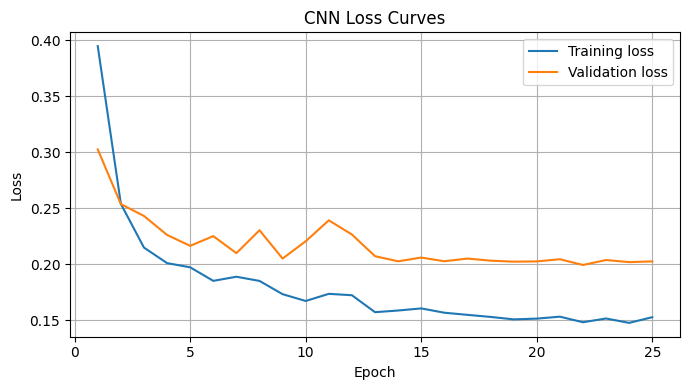

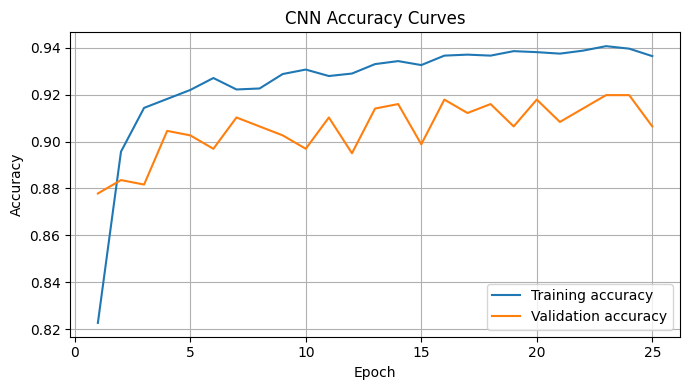

On the VALIDATION SET.
Model average loss: 0.199       Model accuracy: 91.412%

              precision    recall  f1-score   support

           0     0.8409    0.8222    0.8315       135
           1     0.9388    0.9460    0.9424       389

    accuracy                         0.9141       524
   macro avg     0.8898    0.8841    0.8869       524
weighted avg     0.9136    0.9141    0.9138       524



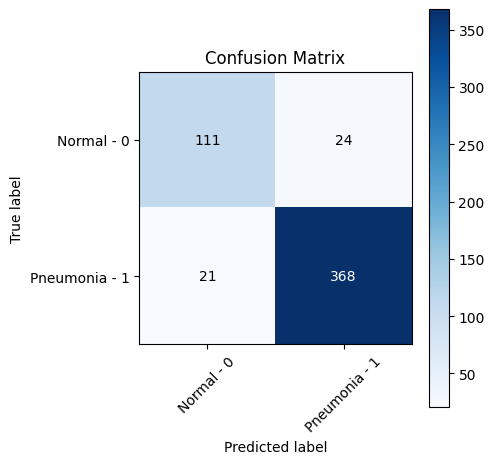

On the TEST SET.
Model average loss: 0.369       Model accuracy: 84.936%

              precision    recall  f1-score   support

           0     0.9430    0.6368    0.7602       234
           1     0.8176    0.9769    0.8902       390

    accuracy                         0.8494       624
   macro avg     0.8803    0.8068    0.8252       624
weighted avg     0.8646    0.8494    0.8414       624



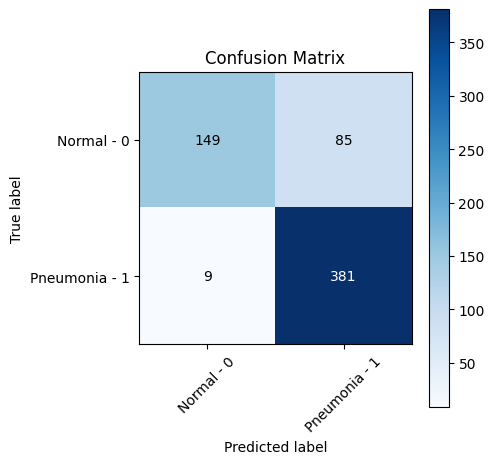

In [20]:
#Training Classifier Head 2.

model_clh = resnet18(weights = weights)

model_clh.fc = torch.nn.Linear(model_clh.fc.in_features, 2)

for p in model_clh.parameters():
    p.requires_grad = False

for p in model_clh.fc.parameters():
    p.requires_grad = True

trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

model_clh_exp2 , best_state_clh_exp2 , results_clh_exp2 = Train_Classifier(
    model = model_clh ,
    initial_lr = 1e-3 ,
    weight_decay = 1e-4 ,
    num_epochs = 25 ,
    training_dataloader = training_dataloader,
    validation_dataloader = validation_dataloader ,
    use_scheduler = True
)

torch.save(results_clh_exp2 , "results_clh_exp2.pt")
torch.save(best_state_clh_exp2 , "best_state_clh_exp2.pt")

Plot_Classifier_Curves(results_clh_exp2)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_exp2 , dataloader = validation_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_exp2 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

In [21]:
batch_size = 32
training_dataloader_32 = DataLoader(training_dataset , batch_size = batch_size , shuffle = True , num_workers = 0)
validation_dataloader_32   = DataLoader(validation_dataset , batch_size = batch_size , shuffle = False , num_workers = 0)

test_dataloader_32 = DataLoader(test_dataset, batch_size = batch_size, shuffle = False , num_workers = 0)

##### Μόνη διαφορά είναι ότι πλέον φροντίζουμε να ενεργοποιήσουμε το requires grad και για τα πρώτα δύο Stages του Resnet.

10494466 11177538
Epoch 01 | Train loss: 0.1440, acc: 0.9467 | Val loss: 0.0944, acc: 0.9637
Epoch 02 | Train loss: 0.0389, acc: 0.9887 | Val loss: 0.0958, acc: 0.9618
Epoch 03 | Train loss: 0.0274, acc: 0.9915 | Val loss: 0.1283, acc: 0.9504
Epoch 04 | Train loss: 0.0134, acc: 0.9966 | Val loss: 0.0898, acc: 0.9676
Epoch 05 | Train loss: 0.0120, acc: 0.9960 | Val loss: 0.0882, acc: 0.9656
Epoch 06 | Train loss: 0.0053, acc: 0.9983 | Val loss: 0.0762, acc: 0.9771
Epoch 07 | Train loss: 0.0029, acc: 0.9994 | Val loss: 0.0811, acc: 0.9733
Epoch 08 | Train loss: 0.0020, acc: 0.9996 | Val loss: 0.0702, acc: 0.9733
Epoch 09 | Train loss: 0.0006, acc: 1.0000 | Val loss: 0.0744, acc: 0.9733
Epoch 10 | Train loss: 0.0015, acc: 1.0000 | Val loss: 0.0924, acc: 0.9676
Training time (minutes): 23.31
Best epoch:  8 with loss  0.07015 and accuracy  97.33 %.
Best validation accuracy:  97.71 % at epoch  6 .


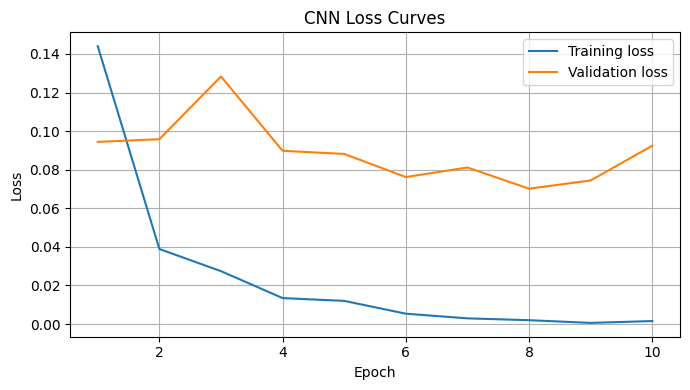

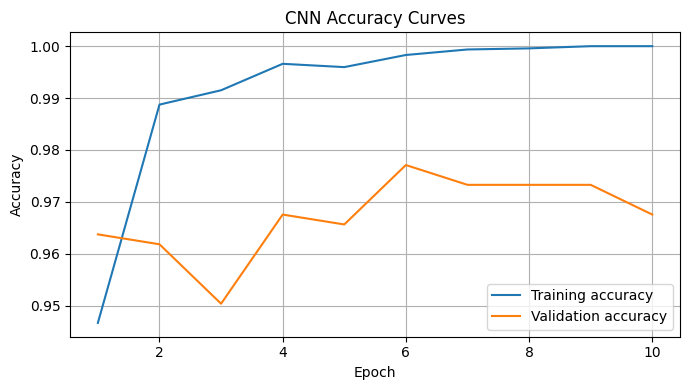

On the VALIDATION SET.
Model average loss: 0.070       Model accuracy: 97.328%

              precision    recall  f1-score   support

           0     0.9618    0.9333    0.9474       135
           1     0.9771    0.9871    0.9821       389

    accuracy                         0.9733       524
   macro avg     0.9695    0.9602    0.9647       524
weighted avg     0.9732    0.9733    0.9731       524



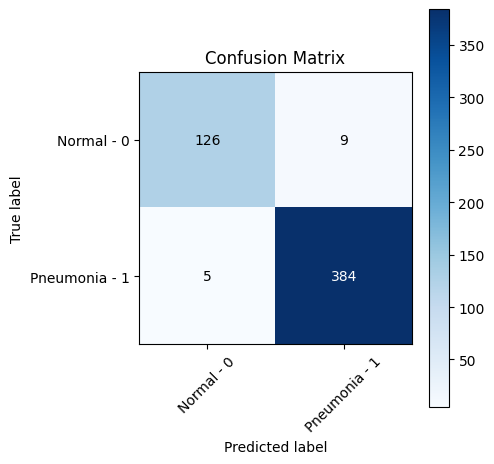

On the TEST SET.
Model average loss: 0.553       Model accuracy: 88.462%

              precision    recall  f1-score   support

           0     1.0000    0.6923    0.8182       234
           1     0.8442    1.0000    0.9155       390

    accuracy                         0.8846       624
   macro avg     0.9221    0.8462    0.8668       624
weighted avg     0.9026    0.8846    0.8790       624



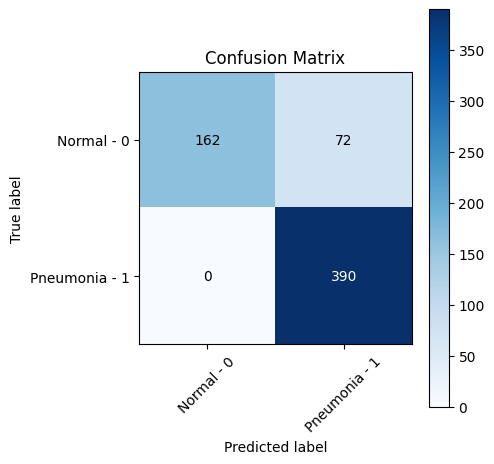

In [22]:
#Feature Extractor 1.

model_fe = resnet18(weights = weights)
model_fe.fc = torch.nn.Linear(model_fe.fc.in_features, 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_exp1 , best_state_fe_exp1 , results_fe_exp1 = Train_Classifier(
    model = model_fe,
    initial_lr = 1e-4 ,
    weight_decay = 0 ,
    num_epochs = 10,
    training_dataloader = training_dataloader_32 ,
    validation_dataloader = validation_dataloader_32 ,
    use_scheduler = True
)

torch.save(results_fe_exp1 , "results_fe_exp1.pt")
torch.save(best_state_fe_exp1 , "best_state_fe_exp1.pt")

Plot_Classifier_Curves(results_fe_exp1)


print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp1 , dataloader = validation_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp1 , dataloader = test_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

10494466 11177538
Epoch 01 | Train loss: 0.1490, acc: 0.9403 | Val loss: 0.0924, acc: 0.9656
Epoch 02 | Train loss: 0.0413, acc: 0.9862 | Val loss: 0.1075, acc: 0.9599
Epoch 03 | Train loss: 0.0169, acc: 0.9947 | Val loss: 0.1183, acc: 0.9695
Epoch 04 | Train loss: 0.0139, acc: 0.9958 | Val loss: 0.0774, acc: 0.9695
Epoch 05 | Train loss: 0.0260, acc: 0.9913 | Val loss: 0.0890, acc: 0.9656
Epoch 06 | Train loss: 0.0095, acc: 0.9972 | Val loss: 0.1443, acc: 0.9485
Epoch 07 | Train loss: 0.0021, acc: 1.0000 | Val loss: 0.0807, acc: 0.9714
Epoch 08 | Train loss: 0.0014, acc: 0.9998 | Val loss: 0.0785, acc: 0.9752
Epoch 09 | Train loss: 0.0010, acc: 1.0000 | Val loss: 0.0700, acc: 0.9752
Epoch 10 | Train loss: 0.0013, acc: 0.9998 | Val loss: 0.0717, acc: 0.9790
Training time (minutes): 23.9
Best epoch:  9 with loss  0.07004 and accuracy  97.52 %.
Best validation accuracy:  97.9 % at epoch  10 .


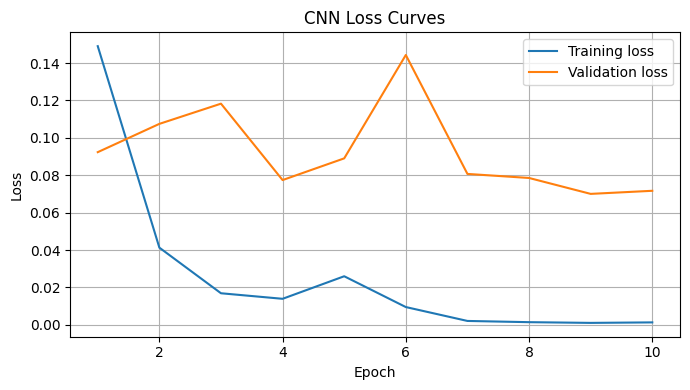

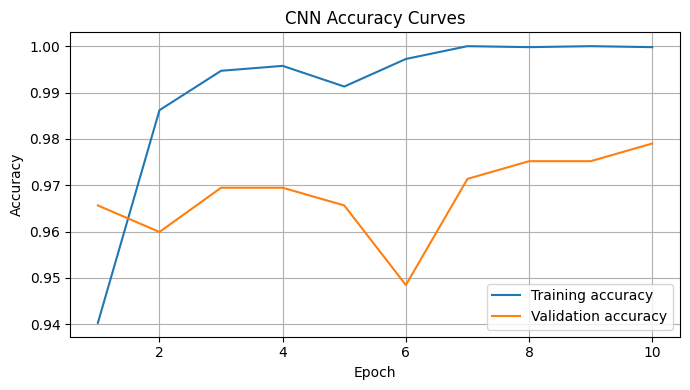

On the VALIDATION SET.
Model average loss: 0.070       Model accuracy: 97.519%

              precision    recall  f1-score   support

           0     0.9485    0.9556    0.9520       135
           1     0.9845    0.9820    0.9833       389

    accuracy                         0.9752       524
   macro avg     0.9665    0.9688    0.9676       524
weighted avg     0.9753    0.9752    0.9752       524



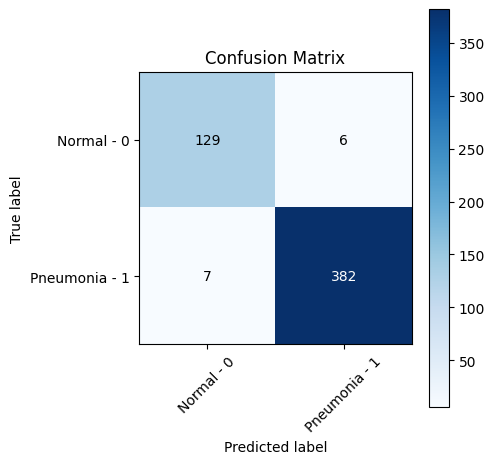

On the TEST SET.
Model average loss: 0.655       Model accuracy: 87.981%

              precision    recall  f1-score   support

           0     1.0000    0.6795    0.8092       234
           1     0.8387    1.0000    0.9123       390

    accuracy                         0.8798       624
   macro avg     0.9194    0.8397    0.8607       624
weighted avg     0.8992    0.8798    0.8736       624



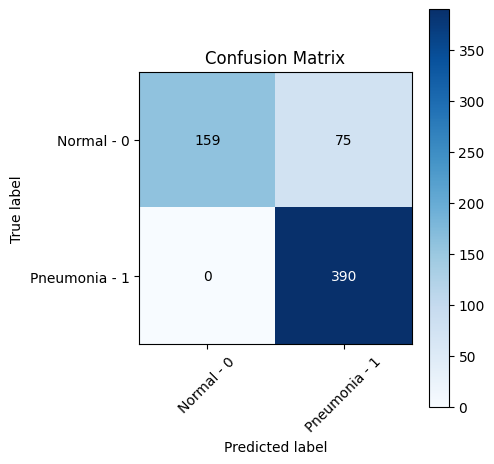

In [23]:
#Feature Extractor 2.

model_fe = resnet18(weights = weights)
model_fe.fc = torch.nn.Linear(model_fe.fc.in_features, 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_exp2 , best_state_fe_exp2 , results_fe_exp2 = Train_Classifier(
    model = model_fe,
    initial_lr = 1e-4 ,
    weight_decay = 1e-4 ,
    num_epochs = 10,
    training_dataloader = training_dataloader_32 ,
    validation_dataloader = validation_dataloader_32 ,
    use_scheduler = True
)

torch.save(results_fe_exp2 , "results_fe_exp2.pt")
torch.save(best_state_fe_exp2 , "best_state_fe_exp2.pt")

Plot_Classifier_Curves(results_fe_exp2)


print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp2 , dataloader = validation_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp2 , dataloader = test_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

Εδώ προσθέτουμε και τα Transforms χωρίς άλλες αλλαγές.

10494466 11177538
Epoch 01 | Train loss: 0.1538, acc: 0.9437 | Val loss: 0.1797, acc: 0.9256
Epoch 02 | Train loss: 0.0971, acc: 0.9658 | Val loss: 0.0823, acc: 0.9714
Epoch 03 | Train loss: 0.0681, acc: 0.9751 | Val loss: 0.1006, acc: 0.9656
Epoch 04 | Train loss: 0.0604, acc: 0.9785 | Val loss: 0.0901, acc: 0.9695
Epoch 05 | Train loss: 0.0501, acc: 0.9830 | Val loss: 0.0816, acc: 0.9618
Epoch 06 | Train loss: 0.0308, acc: 0.9885 | Val loss: 0.0659, acc: 0.9752
Epoch 07 | Train loss: 0.0363, acc: 0.9864 | Val loss: 0.0747, acc: 0.9733
Epoch 08 | Train loss: 0.0194, acc: 0.9943 | Val loss: 0.0984, acc: 0.9637
Epoch 09 | Train loss: 0.0155, acc: 0.9949 | Val loss: 0.0726, acc: 0.9714
Epoch 10 | Train loss: 0.0096, acc: 0.9968 | Val loss: 0.0695, acc: 0.9733
Training time (minutes): 23.65
Best epoch:  6 with loss  0.06585 and accuracy  97.52 %.
Best validation accuracy:  97.52 % at epoch  6 .


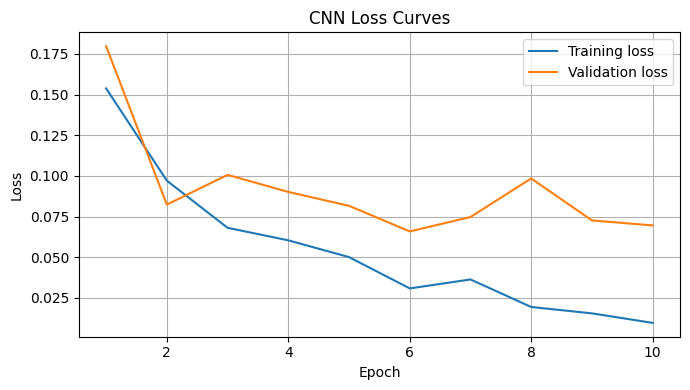

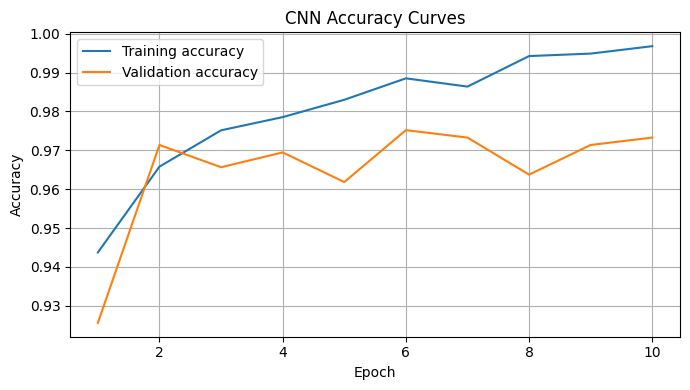

On the VALIDATION SET.
Model average loss: 0.066       Model accuracy: 97.519%

              precision    recall  f1-score   support

           0     0.9357    0.9704    0.9527       135
           1     0.9896    0.9769    0.9832       389

    accuracy                         0.9752       524
   macro avg     0.9626    0.9736    0.9680       524
weighted avg     0.9757    0.9752    0.9753       524



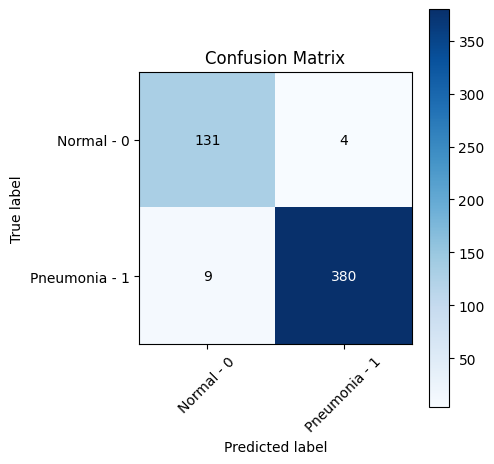

On the TEST SET.
Model average loss: 0.351       Model accuracy: 91.827%

              precision    recall  f1-score   support

           0     0.9946    0.7863    0.8783       234
           1     0.8861    0.9974    0.9385       390

    accuracy                         0.9183       624
   macro avg     0.9403    0.8919    0.9084       624
weighted avg     0.9268    0.9183    0.9159       624



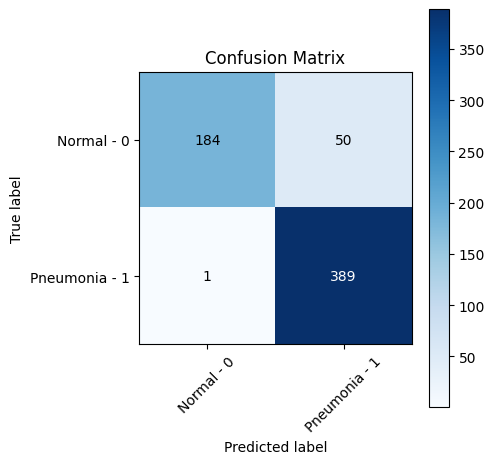

In [24]:
#Feature Extractor 3.

transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224 , scale = (0.9 , 1.0) , ratio = (0.95 , 1.05)) ,
    transforms.RandomRotation(10) ,
    transforms.ToTensor() ,
    transforms.Lambda(lambda x : x.repeat(3 , 1  , 1)),
    transforms.Normalize(mean=[0.485 , 0.456 , 0.406] , std = [0.229 , 0.224,  0.225]) ,
])

training_dataset_aug = PneumoniaMNIST(split="train", download=True, root=root, transform = transform_aug)

batch_size = 32
training_dataloader_32_aug = DataLoader(training_dataset_aug , batch_size = batch_size , shuffle = True , num_workers = 0)

model_fe = resnet18(weights = weights)
model_fe.fc = torch.nn.Linear(model_fe.fc.in_features, 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_exp3 , best_state_fe_exp3 , results_fe_exp3 = Train_Classifier(
    model = model_fe,
    initial_lr = 1e-4 ,
    weight_decay = 5e-4 ,
    num_epochs = 10,
    training_dataloader = training_dataloader_32_aug ,
    validation_dataloader = validation_dataloader_32 ,
    use_scheduler = True
)

torch.save(results_fe_exp3 , "results_fe_exp3.pt")
torch.save(best_state_fe_exp3 , "best_state_fe_exp3.pt")

Plot_Classifier_Curves(results_fe_exp3)


print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp3 , dataloader = validation_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp3 , dataloader = test_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

tensor([1.9390, 0.6737])
10494466 11177538
Epoch 01 | Train loss: 0.1848, acc: 0.9246 | Val loss: 0.1294, acc: 0.9695
Epoch 02 | Train loss: 0.1104, acc: 0.9569 | Val loss: 0.0900, acc: 0.9676
Epoch 03 | Train loss: 0.0826, acc: 0.9681 | Val loss: 0.1166, acc: 0.9408
Epoch 04 | Train loss: 0.0629, acc: 0.9788 | Val loss: 0.1125, acc: 0.9447
Epoch 05 | Train loss: 0.0520, acc: 0.9800 | Val loss: 0.0687, acc: 0.9733
Epoch 06 | Train loss: 0.0436, acc: 0.9862 | Val loss: 0.0768, acc: 0.9695
Epoch 07 | Train loss: 0.0454, acc: 0.9843 | Val loss: 0.1138, acc: 0.9599
Epoch 08 | Train loss: 0.0406, acc: 0.9858 | Val loss: 0.1606, acc: 0.9695
Epoch 09 | Train loss: 0.0184, acc: 0.9941 | Val loss: 0.0667, acc: 0.9771
Epoch 10 | Train loss: 0.0146, acc: 0.9962 | Val loss: 0.0959, acc: 0.9656
Training time (minutes): 23.78
Best epoch:  9 with loss  0.06669 and accuracy  97.71 %.
Best validation accuracy:  97.71 % at epoch  9 .


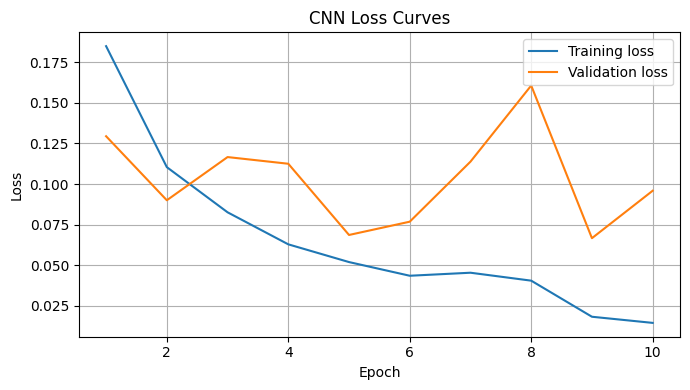

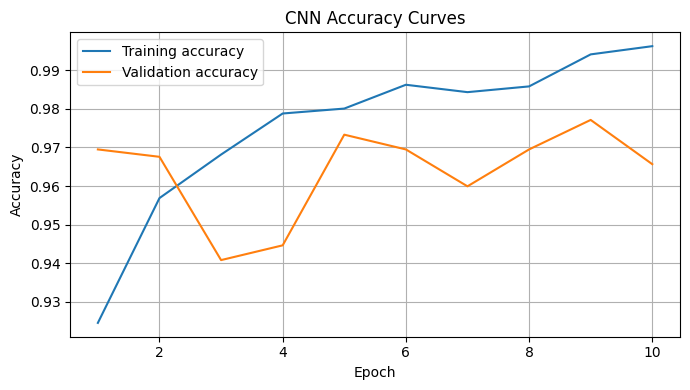

On the VALIDATION SET.
Model average loss: 0.081       Model accuracy: 97.710%

              precision    recall  f1-score   support

           0     0.9362    0.9778    0.9565       135
           1     0.9922    0.9769    0.9845       389

    accuracy                         0.9771       524
   macro avg     0.9642    0.9773    0.9705       524
weighted avg     0.9777    0.9771    0.9773       524



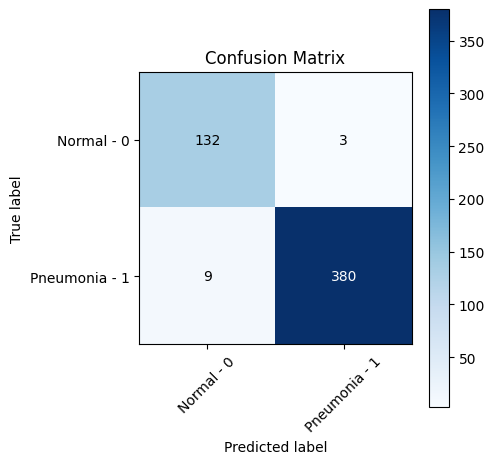

On the TEST SET.
Model average loss: 0.325       Model accuracy: 91.827%

              precision    recall  f1-score   support

           0     0.9791    0.7991    0.8800       234
           1     0.8915    0.9897    0.9380       390

    accuracy                         0.9183       624
   macro avg     0.9353    0.8944    0.9090       624
weighted avg     0.9243    0.9183    0.9163       624



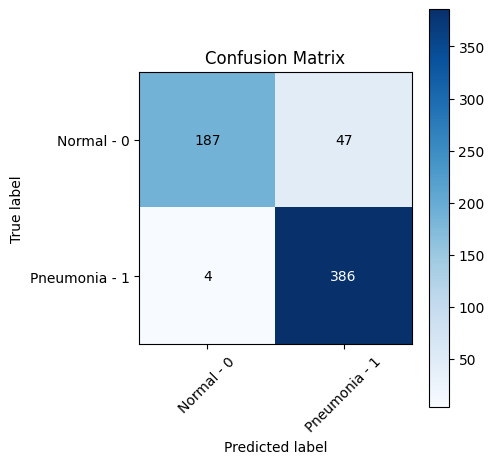

In [31]:
#Feature Extractor 4.
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224 , scale = (0.9 , 1.0) , ratio = (0.95 , 1.05)) ,
    transforms.RandomRotation(10) ,
    transforms.ToTensor() ,
    transforms.Lambda(lambda x : x.repeat(3 , 1  , 1)),
    transforms.Normalize(mean=[0.485 , 0.456 , 0.406] , std = [0.229 , 0.224,  0.225]) ,
])

training_dataset_aug = PneumoniaMNIST(split="train", download=True, root=root, transform = transform_aug)

batch_size = 32
training_dataloader_32_aug = DataLoader(training_dataset_aug , batch_size = batch_size , shuffle = True , num_workers = 0)

model_fe = resnet18(weights = weights)
model_fe.fc = torch.nn.Linear(model_fe.fc.in_features, 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_exp4 , best_state_fe_exp4 , results_fe_exp4 = Train_Classifier(
    model = model_fe,
    initial_lr = 1e-4 ,
    weight_decay = 5e-4 ,
    num_epochs = 10,
    training_dataloader = training_dataloader_32_aug ,
    validation_dataloader = validation_dataloader_32 ,
    use_scheduler = True , 
    weight = weight
)

torch.save(results_fe_exp4 , "results_fe_exp4.pt")
torch.save(best_state_fe_exp4 , "best_state_fe_exp4.pt")

Plot_Classifier_Curves(results_fe_exp4)


print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp4 , dataloader = validation_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_exp4 , dataloader = test_dataloader_32)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)